# Run the analyses
## Prerequisites
# Install the environment
Using conda, run the following and then select the created environment's kernel for executing this notebook.

In [ ]:
!conda env create -f env.yml -n myenv
!source activate myenv
!python -m ipykernel install --user --name myenv

Then use the installed environment's kernel to run this notebook.

# Setup
Required imports, loading data and experiment configuration.

In [1]:
import os
from pathlib import Path

import pandas as pd
from src.util import generate_general_stats, save_dict_as_csv
import warnings

from src.config import AggregationConfig, ExperimentConfig

pd.set_option('future.no_silent_downcasting', True)
warnings.filterwarnings("ignore", category=FutureWarning)
Path("./figures").mkdir(exist_ok=True)


In [2]:
# This is the data after QC steps but before RQ-specific filtering steps as downloaded from Zenodo
df = pd.read_parquet("data.parquet")
generate_general_stats(df, fp=Path("./data/stats_post_QC.dat"))
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6529297 entries, 210036 to 9104766
Data columns (total 7 columns):
 #   Column           Dtype         
---  ------           -----         
 0   conversation_id  object        
 1   sender_id        object        
 2   datetime         datetime64[ns]
 3   word_count       int64         
 4   data_source_id   int64         
 5   donor_id         object        
 6   id               object        
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 398.5+ MB


## Filtering & Transforming
Filtering steps specific to the research questions:
- Only chats with 10% <= x <= 90% messages by both chat partners
- Only chats with at least 100 messages sent
- For the LMM only: remove donations with < 5 chats
- Transform the data: Create the response time column, merge consecutive messages by the same sender into one.

In [4]:
lmm_config = ExperimentConfig(**{
    "round_to_minute": True, # round non-uniform timestamps (between iOS and Android) uniformly to minutes
    "temporal_resolution": "minute", # unit of interpretation (minutes or seconds)
    "conversation_min_msg_threshold": 100, # discard chats with < 100 messages
    "exclude_donations_lt_n_chats": 5, # discard donations with < 5 chats (after other filters)
    "system_message_filtering_threshold": 10, # Remove messages by chat participants that have <= 10 messages in group chats
    "aggregation": AggregationConfig(**{
        "message_aggregation": "conversation", # level/layer of aggregation
        "aggregation_period": 5, # With temporal resolution of minutes, this amounts to the probability of a reply within 5 minutes. 
        "aggregation_type": "probability",
    }),
    "block_merge": "first",
    "model": "Lmer", # Uses Lmer R library
    "lmm_formula": "rt_ego ~ rt_prev_alter + (1|donor_id)", # Lmer formula: Predict 
    "predictors": ["rt_prev_alter"],
    "optimizer": "optimx",
    "distribution": "gaussian",
    "n_boot": 500, # Number of bootstrap intervals if bootstrapped confidence intervals are requested
    "optCtrl": {
        "method": "bobyqa",
    }
    })
lmm_config

ExperimentConfig(
  block_merge='first',
  rt_threshold=None,
  wc_threshold=None,
  conversation_min_wc_threshold=None,
  conversation_min_msg_threshold=100,
  exclude_donations_lt_n_chats=5,
  rt_minimum_threshold=None,
  conversation_gap=ConversationGapFilteringConfig(top_n=None, gap_fraction=None, rt_max_gap_filter=None),
  system_message_filtering_threshold=10,
  jsd_base=2,
  lmm_formula='rt_ego ~ rt_prev_alter + (1|donor_id)',
  n_boot=500,
  predictors=['rt_prev_alter'],
  round_to_minute=True,
  temporal_resolution='minute',
  filter_temporal_resolution=None,
  model='Lmer',
  experiment_name=None,
  optimizer='optimx',
  optCtrl={'method': 'bobyqa'},
  aggregation=AggregationConfig(message_aggregation='conversation', aggregation_type='probability', aggregation_period=5),
  distribution='gaussian'
)

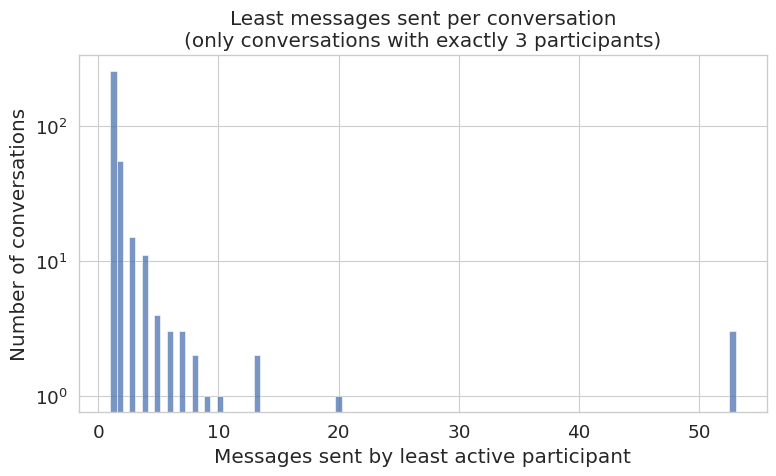

232     8
214     9
246    10
172    13
29     13
5      20
343    53
314    53
33     53
Name: min_messages, dtype: int64


In [5]:
# System message filtering threshold
import seaborn as sns
import matplotlib.pyplot as plt

sys_df = df[df.data_source_id == 2]  # WA only
exactly_n_group_members = 3

# Count messages per sender per conversation
msg_counts = sys_df.groupby(["conversation_id", "sender_id"]).size().reset_index(name="n_messages")

# For each conversation, get the number of unique participants
participant_counts = (
    sys_df.groupby("conversation_id")["sender_id"].nunique().reset_index(name="n_participants")
)

# Keep only conversations with exactly n participants
valid_conversations = participant_counts[
    participant_counts["n_participants"] == exactly_n_group_members
]["conversation_id"]

filtered_counts = msg_counts[msg_counts["conversation_id"].isin(valid_conversations)]

# For each conversation, get the minimum number of messages sent by any participant
min_msgs = (
    filtered_counts.groupby("conversation_id")["n_messages"].min().reset_index(name="min_messages")
)

# Plot with seaborn
sns.set_theme(style="whitegrid", context="paper", font_scale=1.5)

plt.figure(figsize=(8, 5))
sns.histplot(
    data=min_msgs,
    x="min_messages",
    bins=100,
    element="bars",
    kde=False,
    fill=True,
)
plt.yscale("log")
plt.xlabel("Messages sent by least active participant")
plt.ylabel("Number of conversations")
plt.title(
    f"Least messages sent per conversation\n(only conversations with exactly {exactly_n_group_members} participants)"
)
plt.tight_layout()
plt.savefig("./figures/system_messages.pdf")
plt.show()
print(min_msgs["min_messages"].sort_values()[-9:])


In [6]:
from src.etl import add_columns, filter_system_messages, filter_unidirectional_chats, transform_data, filter_groups

df = filter_system_messages(df, message_count_threshold=lmm_config.system_message_filtering_threshold, triads_only=True)
df = filter_groups(df)
df = filter_unidirectional_chats(df)
df = add_columns(df)

Identified 86 system senders to remove.
Group conversations went from 621 to 287
Filtering system messages removes 1854/6529297 messages (0.00%)
Remaining WA groups: 187
<class 'pandas.core.frame.DataFrame'>
N group chats (before actual filtering): 287
Filtering group chats removes 1544586/6527443 messages (23.66%)
N group chats (after actual filtering): 0
Unidirectional chats filter: Conversation_ids to retain: 4789/5275. This removes 92079/4982857 messages (1.85%)


In [7]:
response_probability_df = transform_data(experiment_config=lmm_config, df=df, plotting_transforms=False)
response_probability_df.to_parquet("response_probability_df.parquet")

A message limit of >= 100 messages per chat removes 65283/4890778 rows (1.33%) and 3637/4789 convs.
Removed donors: {'e9f61539-78e3-4a26-9290-81294ec486bf', 'd2378a10-125d-40f1-9d66-3e53cbc4bf9f', '9ed0ea9f-3b72-4c3e-8d2d-86b27ba16fa6', '71027f65-a922-4a70-b15b-f9663dbb7ce8', '5c9df3e9-e633-4c99-a2ff-583cc0fb7791', 'bd82e4b3-0d04-4e26-a158-fa43453971d3', '41104d7c-b774-40b4-8e45-b5404bf3b5aa', 'dc1f5c93-4cde-4700-b794-8cab5dad34d8'}
Reducing block messages to one per block removes 2423218/4825495 messages (50.22%)
Removing NaN (due to data transform) removes 1202399/2402277 messages (50.05%)
Rounding rt_ego
Rounding rt_prev_alter
Removing donations with < 5 chats removes 364421/1199878 rows (30.37%) or 84/181 donations
In aggregate() - probability: Index(['conversation_id', 'word_count', 'data_source_id', 'donor_id', 'id',
       'rt_ego', 'rt_prev_alter', 'wc_prev_alter', 'hour', 'weekday'],
      dtype='object')
End of aggregate(): Index(['donor_id', 'conversation_id', 'word_count', 

In [8]:
response_time_config = ExperimentConfig(**{
    "round_to_minute": True, # round non-uniform timestamps (between iOS and Android) uniformly to minutes
    "block_merge": "first",
    "temporal_resolution": "minute", # unit of interpretation (minutes or seconds)
    "conversation_min_msg_threshold": 100, # discard chats with < 100 messages
    "exclude_donations_lt_n_chats": 5,
    "jsd_base": 2, # Base for the logarithm for calculating the JSD
    })
stats_df = transform_data(experiment_config=response_time_config, df=df, plotting_transforms=True, skip_merge=True)
generate_general_stats(stats_df, fp=Path("./data/stats_RQ.dat")) # Data as used for answering the RQs, uses the number of messages after all processing but skipping the merging of consecutive messages
response_time_df = transform_data(experiment_config=response_time_config, df=df, plotting_transforms=True)
response_time_df.to_parquet("response_time_df.parquet")

A message limit of >= 100 messages per chat removes 65283/4890778 rows (1.33%) and 3637/4789 convs.
Removed donors: {'e9f61539-78e3-4a26-9290-81294ec486bf', 'd2378a10-125d-40f1-9d66-3e53cbc4bf9f', '9ed0ea9f-3b72-4c3e-8d2d-86b27ba16fa6', '71027f65-a922-4a70-b15b-f9663dbb7ce8', '5c9df3e9-e633-4c99-a2ff-583cc0fb7791', 'bd82e4b3-0d04-4e26-a158-fa43453971d3', '41104d7c-b774-40b4-8e45-b5404bf3b5aa', 'dc1f5c93-4cde-4700-b794-8cab5dad34d8'}
Removing NaN (due to data transform) removes 2721/4825495 messages (0.06%)
Rounding rt
Removing donations with < 5 chats removes 1399199/4822774 rows (29.01%) or 84/181 donations
A message limit of >= 100 messages per chat removes 65283/4890778 rows (1.33%) and 3637/4789 convs.
Removed donors: {'e9f61539-78e3-4a26-9290-81294ec486bf', 'd2378a10-125d-40f1-9d66-3e53cbc4bf9f', '9ed0ea9f-3b72-4c3e-8d2d-86b27ba16fa6', '71027f65-a922-4a70-b15b-f9663dbb7ce8', '5c9df3e9-e633-4c99-a2ff-583cc0fb7791', 'bd82e4b3-0d04-4e26-a158-fa43453971d3', '41104d7c-b774-40b4-8e45-b5

In [9]:
response_time_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1671972 entries, 1 to 2402276
Data columns (total 12 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   conversation_id  1671972 non-null  object        
 1   sender_id        1671972 non-null  object        
 2   datetime         1671972 non-null  datetime64[ns]
 3   word_count       1671972 non-null  int64         
 4   data_source_id   1671972 non-null  int64         
 5   donor_id         1671972 non-null  object        
 6   id               1671972 non-null  object        
 7   sender           1671972 non-null  object        
 8   rt               1671972 non-null  float64       
 9   wc_prev_alter    835996 non-null   float64       
 10  hour             1671972 non-null  category      
 11  weekday          1671972 non-null  category      
dtypes: category(2), datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 143.5+ MB


In [10]:
response_time_df.rt.mean() # 214.7 with keep=first, 418 with keep=last

np.float64(214.71767170742095)

In [11]:
response_time_df.shape[0] # 1,671,972 rows

1671972

## Fit LMM
Fit a linear mixed model on the association of alter's probability of responding within 5min to ego's probability of responding within 5min (`rt_ego ~ rt_prev_alter + (1|donor_id)`), separated by data source (2 for WhatsApp, 3 for Instagram).


In [12]:
def store_results(lmm_res_df, fp):
    col_map = {
        "Estimate": "est",
        "2.5_ci": "ci_lo",
        "97.5_ci": "ci_hi",
        "SE": "se",
        "DF": "df",
        "T-stat": "t",
        "P-val": "p",
    }

    df_clean = lmm_res_df.drop(columns=["Sig"]).rename(columns=col_map, index={"(Intercept)": "intercept"})

    flat = {
        f"{row}_{col}": val
        for row, data in df_clean.iterrows()
        for col, val in data.items()
    }
    save_dict_as_csv(flat, fp, precision=3)

In [13]:
from src.models import LMM
import pandas as pd

response_probability_df = pd.read_parquet("response_probability_df.parquet")
wa_experiment = LMM(lmm_config)
wa_res = wa_experiment.fit_lmm(response_probability_df[response_probability_df.data_source_id==2])
wa_res

During startup - Warning messages:
1: Setting LC_PAPER failed, using "C" 
2: Setting LC_MEASUREMENT failed, using "C" 


Fitting linear model using lmer with Wald confidence intervals...



R[write to console]: Loading required namespace: optimx

R[write to console]: In addition: 
R[write to console]: Warning messages:

R[write to console]: 1: 
R[write to console]: In model.matrix.default(fixedform, fr, contrasts) :
R[write to console]: 
 
R[write to console]:  variable 'donor_id' is absent, its contrast will be ignored

R[write to console]: 2: 
R[write to console]: In model.matrix.default(fixedform, fr, contrasts) :
R[write to console]: 
 
R[write to console]:  variable 'conversation_id' is absent, its contrast will be ignored

R[write to console]: 3: 
R[write to console]: In model.matrix.default(fixedform, fr, contrasts) :
R[write to console]: 
 
R[write to console]:  variable 'donor_id' is absent, its contrast will be ignored

R[write to console]: 4: 
R[write to console]: In model.matrix.default(fixedform, fr, contrasts) :
R[write to console]: 
 
R[write to console]:  variable 'conversation_id' is absent, its contrast will be ignored



Linear mixed model fit by REML [’lmerMod’]
Formula: rt_ego~rt_prev_alter+(1|donor_id)

Family: gaussian	 Inference: parametric

Number of observations: 344	 Groups: {'donor_id': 64.0}

Log-likelihood: 405.340 	 AIC: -802.680

Random effects:

                 Name    Var    Std
donor_id  (Intercept)  0.003  0.055
Residual               0.004  0.063

No random effect correlations specified

Fixed effects:

Warning messages:
1: In model.matrix.default(fixedform, fr, contrasts) :
  variable 'donor_id' is absent, its contrast will be ignored
2: In model.matrix.default(fixedform, fr, contrasts) :
  variable 'conversation_id' is absent, its contrast will be ignored
3: In model.matrix.default(fixedform, fr, contrasts) :
  variable 'donor_id' is absent, its contrast will be ignored
4: In model.matrix.default(fixedform, fr, contrasts) :
  variable 'conversation_id' is absent, its contrast will be ignored

AIC -802.679772313869
BIC -787.3172056843754
log likelihood 405.3398861569345
ICC 0.432118

,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.115,0.083,0.146,0.016,285.439,7.083,0.0,***
rt_prev_alter,0.786,0.739,0.834,0.024,340.108,32.498,0.0,***


{'const': 11.708328934285314, 'rt_prev_alter': 1.0}
Var_explained_percent 89.62572695850103
Breusch-Pagan (heteroscedasticity): {'Lagrange multiplier statistic': np.float64(3.9372666596832726), 'p-value': np.float64(0.047227454950391344), 'f-value': np.float64(3.9596964489023487), 'f p-value': np.float64(0.047398025974005206)}
Durbin Watson autocorrelation: 2.192111996727835
Shapiro-Wilk residuals p-value 6.44913983167356e-05


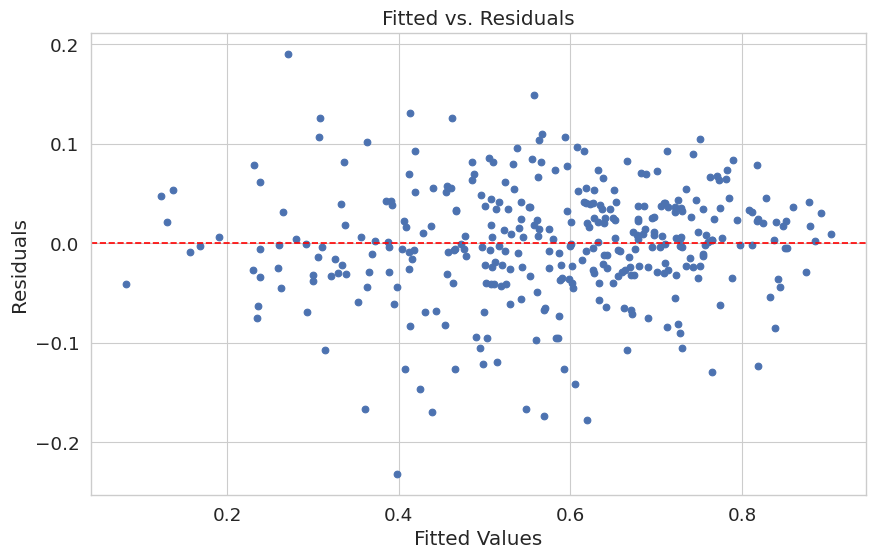

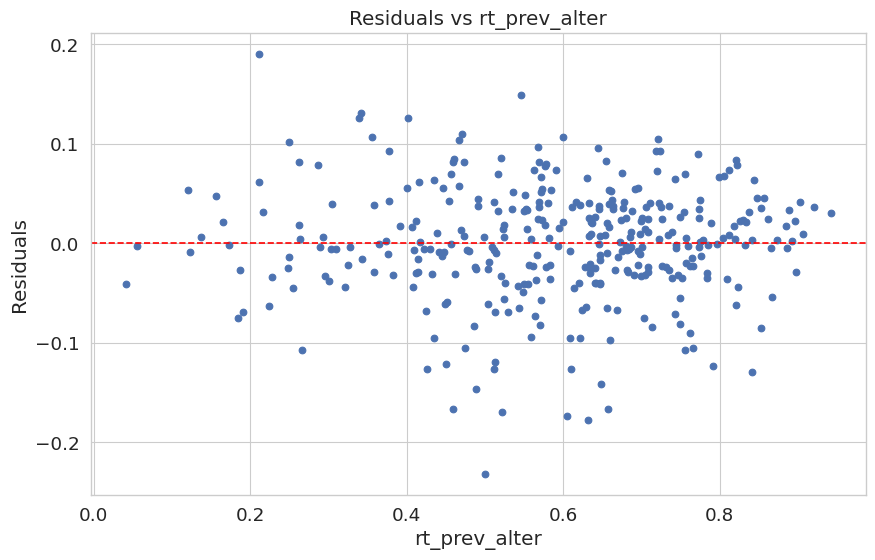

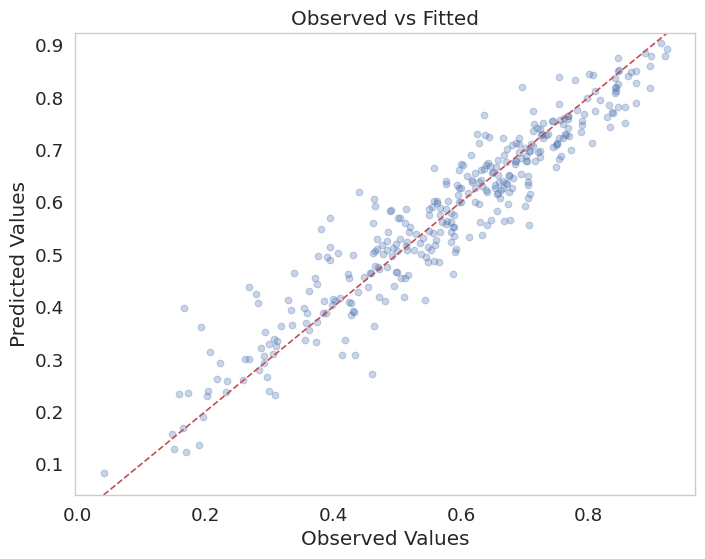

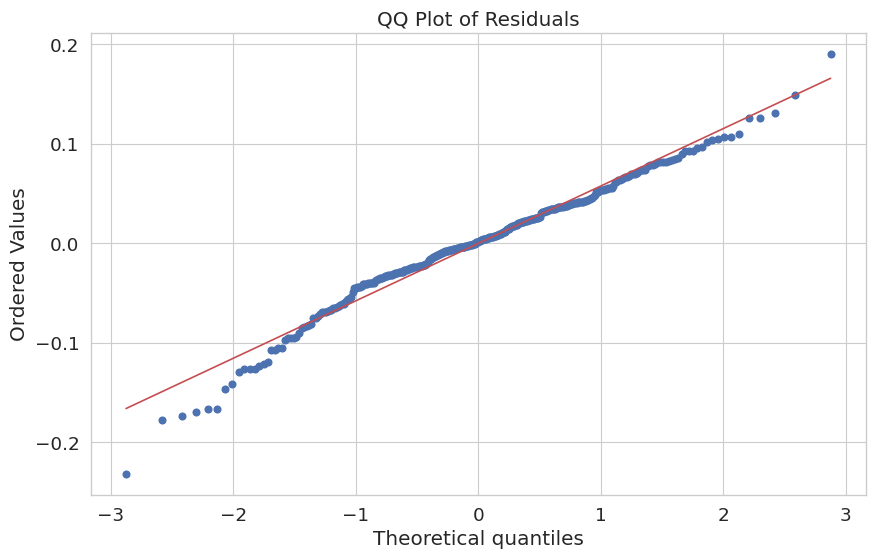

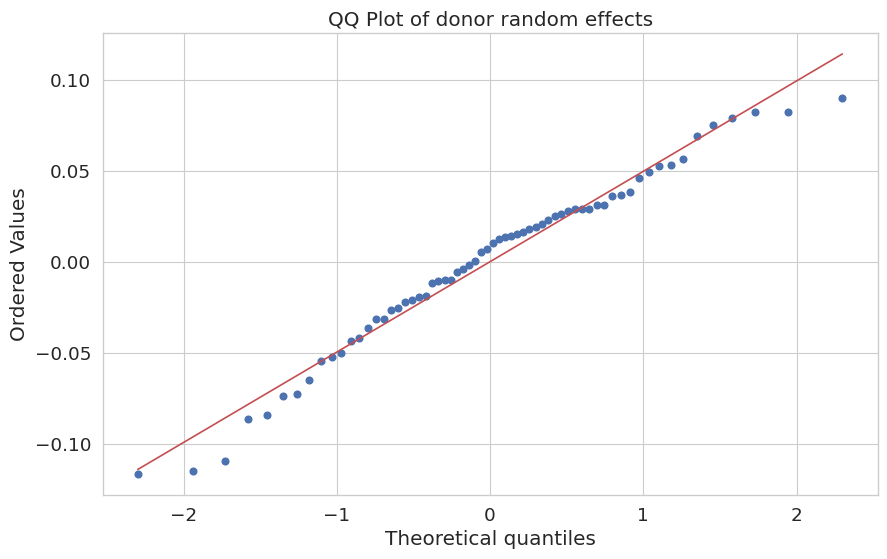

In [14]:
store_results(wa_res, Path("./data/wa_lmm.dat"))
wa_experiment.eval_model()

In [15]:
from src.models import LMM
import pandas as pd
response_probability_df = pd.read_parquet("response_probability_df.parquet")
ig_experiment = LMM(lmm_config)
ig_res = ig_experiment.fit_lmm(response_probability_df[response_probability_df.data_source_id==3])
ig_res

Fitting linear model using lmer with Wald confidence intervals...



R[write to console]: In addition: 
R[write to console]: Warning messages:

R[write to console]: 1: 
R[write to console]: In model.matrix.default(fixedform, fr, contrasts) :
R[write to console]: 
 
R[write to console]:  variable 'donor_id' is absent, its contrast will be ignored

R[write to console]: 2: 
R[write to console]: In model.matrix.default(fixedform, fr, contrasts) :
R[write to console]: 
 
R[write to console]:  variable 'conversation_id' is absent, its contrast will be ignored

R[write to console]: 3: 
R[write to console]: In model.matrix.default(fixedform, fr, contrasts) :
R[write to console]: 
 
R[write to console]:  variable 'donor_id' is absent, its contrast will be ignored

R[write to console]: 4: 
R[write to console]: In model.matrix.default(fixedform, fr, contrasts) :
R[write to console]: 
 
R[write to console]:  variable 'conversation_id' is absent, its contrast will be ignored



Linear mixed model fit by REML [’lmerMod’]
Formula: rt_ego~rt_prev_alter+(1|donor_id)

Family: gaussian	 Inference: parametric

Number of observations: 545	 Groups: {'donor_id': 33.0}

Log-likelihood: 482.750 	 AIC: -957.501

Random effects:

                 Name    Var    Std
donor_id  (Intercept)  0.006  0.077
Residual               0.009  0.092

No random effect correlations specified

Fixed effects:

Warning messages:
1: In model.matrix.default(fixedform, fr, contrasts) :
  variable 'donor_id' is absent, its contrast will be ignored
2: In model.matrix.default(fixedform, fr, contrasts) :
  variable 'conversation_id' is absent, its contrast will be ignored
3: In model.matrix.default(fixedform, fr, contrasts) :
  variable 'donor_id' is absent, its contrast will be ignored
4: In model.matrix.default(fixedform, fr, contrasts) :
  variable 'conversation_id' is absent, its contrast will be ignored

AIC -957.5007150191132
BIC -940.2975718404601
log likelihood 482.7503575095566
ICC 0.40728

,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.061,0.029,0.093,0.016,48.807,3.735,0.0,***
rt_prev_alter,0.796,0.758,0.834,0.020,541.629,40.636,0.0,***


{'const': 4.405060418207877, 'rt_prev_alter': 1.0}
Var_explained_percent 87.18269652475026
Breusch-Pagan (heteroscedasticity): {'Lagrange multiplier statistic': np.float64(6.216351502193252), 'p-value': np.float64(0.012657568799578413), 'f-value': np.float64(6.264998715351097), 'f p-value': np.float64(0.012607245325619723)}
Durbin Watson autocorrelation: 2.106529652242169
Shapiro-Wilk residuals p-value 0.00013559104643998796


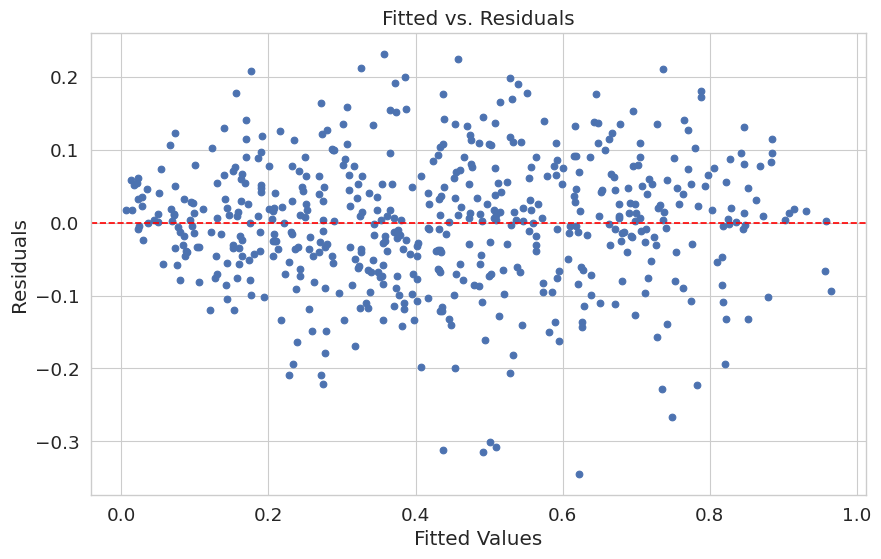

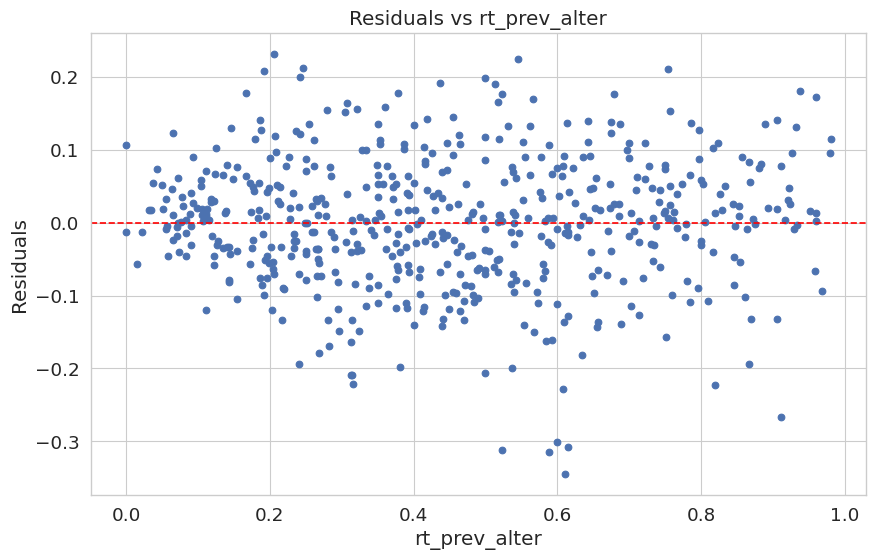

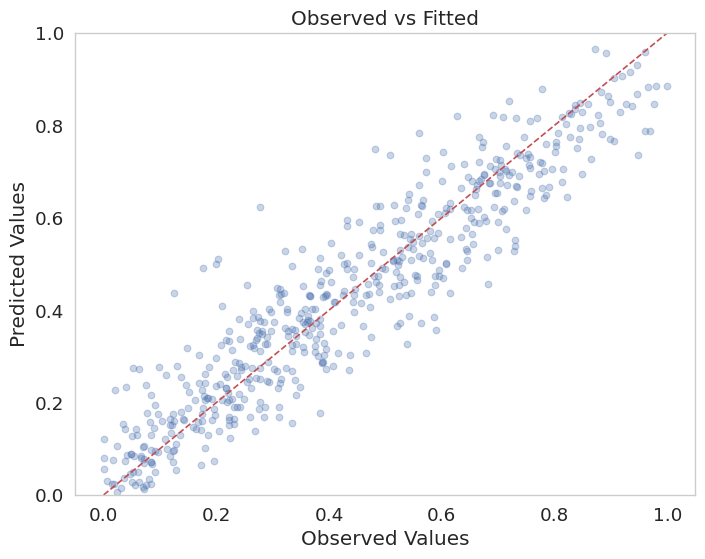

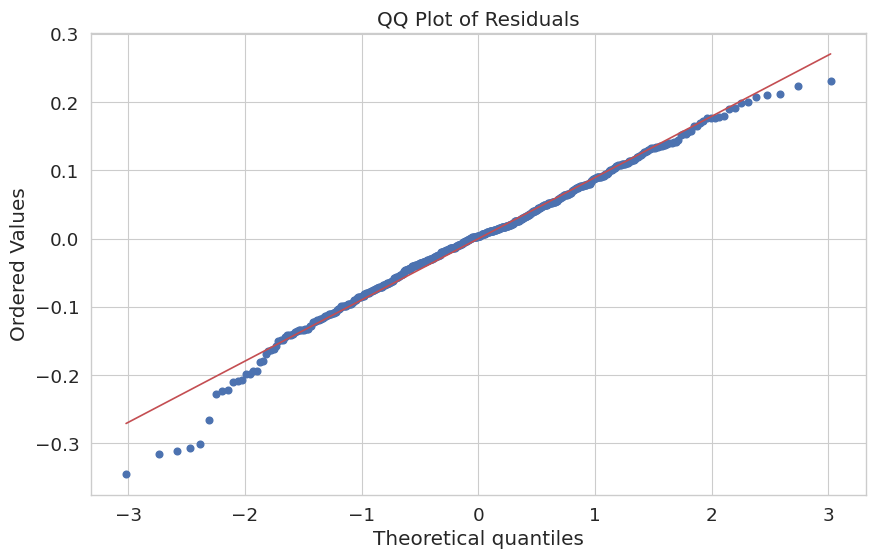

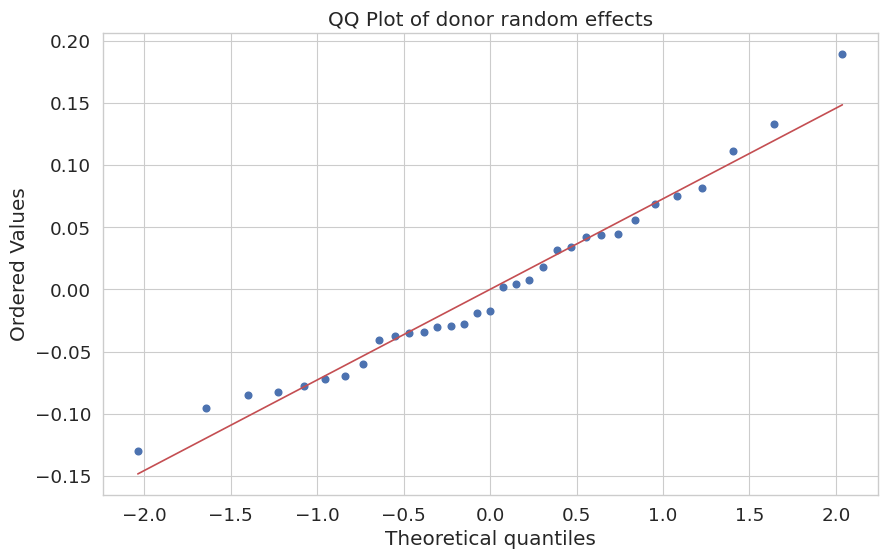

In [16]:
store_results(ig_res, Path("./data/ig_lmm.dat"))
ig_experiment.eval_model()

## Plots

Ordered by appearance in the paper.

In [17]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import jensenshannon

# sns.set_theme(context="paper")
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Creating legend with loc.*")

response_time_df = pd.read_parquet("response_time_df.parquet")

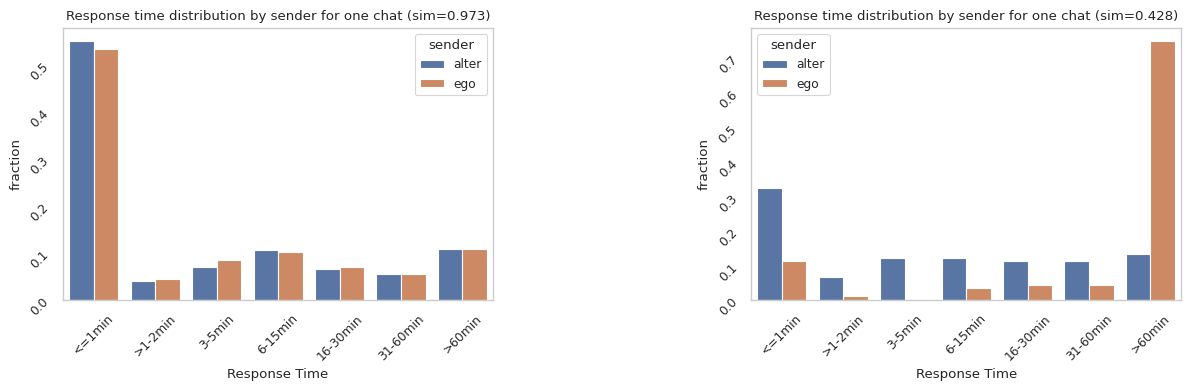

In [ ]:

sns.set_theme(context="paper")
sns.set_style("whitegrid")
plot_df = response_time_df.copy()

# Define bins and labels
# bin_edges = [0, 60, 120, 300, 900, 1800, 3600, float("inf")]
bin_edges = [0, 1, 2, 5, 15, 30, 60, float("inf")]
bin_labels = ["<=1min", ">1-2min", "3-5min", "6-15min", "16-30min", "31-60min", ">60min"]

plot_df.rt = plot_df.rt.fillna(pd.Timedelta(seconds=0))

# Bin the response times
plot_df["rt_bin"] = pd.cut(plot_df["rt"], bins=bin_edges, labels=bin_labels, right=True)

# Initialize list to hold distances
jsd_dict = {}

# Group by conversation
for conv_id, group in plot_df.groupby("conversation_id"):
    counts = group.groupby(["sender", "rt_bin"]).size().unstack(fill_value=0)

    # Skip if either group is missing
    if "ego" not in counts.index or "alter" not in counts.index:
        continue

    # Get raw counts
    ego_dist = counts.loc["ego"].values
    alter_dist = counts.loc["alter"].values

    # Skip if either group has no values (sum == 0)
    if ego_dist.sum() == 0 or alter_dist.sum() == 0:
        continue

    # Normalize to probability distributions
    ego_dist = ego_dist / ego_dist.sum()
    alter_dist = alter_dist / alter_dist.sum()

    # Compute JSD
    jsd = 1.0 - jensenshannon(ego_dist, alter_dist, base=response_time_config.jsd_base)
    jsd_dict.update({conv_id: jsd})

jsd_sorted = {k: float(v) for k, v in sorted(jsd_dict.items(), key=lambda item: item[1])}
low_jsd_conv_id = list(jsd_sorted.keys())[-5]
high_jsd_conv_id = list(jsd_sorted.keys())[2]

# Count how many responses fall in each bin per sender group
low_bin_counts = (
    plot_df[plot_df.conversation_id == low_jsd_conv_id]
    .groupby(["sender", "rt_bin"])
    .size()
    .reset_index(name="count")
)

high_bin_counts = (
    plot_df[plot_df.conversation_id == high_jsd_conv_id]
    .groupby(["sender", "rt_bin"])
    .size()
    .reset_index(name="count")
)

low_bin_counts["fraction"] = low_bin_counts.groupby("sender")["count"].transform(
    lambda x: x / x.sum()
)
high_bin_counts["fraction"] = high_bin_counts.groupby("sender")["count"].transform(
    lambda x: x / x.sum()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)
axes = axes.flatten()
sns.barplot(data=low_bin_counts, x="rt_bin", y="fraction", hue="sender", ax=axes[0])
axes[0].set_title(
    f"Response time distribution by sender for one chat (sim={jsd_sorted[low_jsd_conv_id]:.3f})"
)
sns.barplot(data=high_bin_counts, x="rt_bin", y="fraction", hue="sender", ax=axes[1])
axes[1].set_title(
    f"Response time distribution by sender for one chat (sim={jsd_sorted[high_jsd_conv_id]:.3f})"
)
axes[0].tick_params(labelrotation=45)
axes[1].tick_params(labelrotation=45)
axes[0].set_xlabel("Response Time")
axes[1].set_xlabel("Response Time")
axes[0].grid(False)
axes[1].grid(False)

plt.tight_layout()
fig.subplots_adjust(wspace=0.6)
plt.savefig("./figures/rt_hist_sim.pdf")
plt.show()

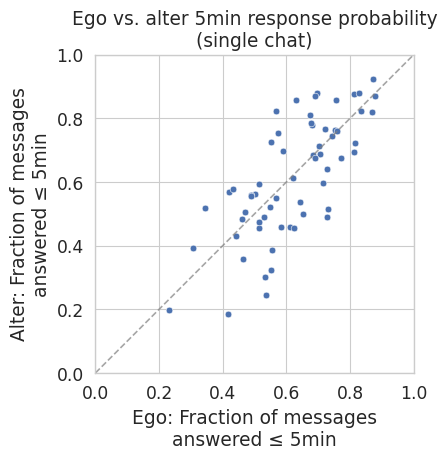

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper", font_scale=1.4)

# Filter only messages from the relevant donor_id
donor_id = "69325d2f-f3ff-4d46-99da-4785a152dd5f"
# donor_id = "b0333fe9-c87a-484e-902c-404ff1e28a7f"
plot_df = response_time_df[response_time_df.donor_id == donor_id].copy()

fractions = []
rt_cutoff = 5

# Group by conversation
for conv_id, group in plot_df.groupby("conversation_id"):
    # Split ego and alter messages
    ego_msgs = group[group.sender_id == donor_id]
    alter_msgs = group[group.sender_id != donor_id]

    # Compute fractions (handling possible zero messages)
    ego_frac = (ego_msgs.rt <= rt_cutoff).mean() if not ego_msgs.empty else None
    alter_frac = (alter_msgs.rt <= rt_cutoff).mean() if not alter_msgs.empty else None

    fractions.append(
        {"conversation_id": conv_id, "ego_fraction": ego_frac, "alter_fraction": alter_frac}
    )

# Create a dataframe
frac_df = pd.DataFrame(fractions).dropna()

# Plot
plt.plot([0, 1], [0, 1], color="grey", ls="--", alpha=0.7)
sns.scatterplot(data=frac_df, x="ego_fraction", y="alter_fraction")
plt.xlabel(f"Ego: Fraction of messages\nanswered ≤ {rt_cutoff}min")
plt.ylabel(f"Alter: Fraction of messages\nanswered ≤ {rt_cutoff}min")
plt.title("Ego vs. alter 5min response probability\n(single chat)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.savefig("./figures/ego_alter_rp_scatterplot.pdf")
plt.show()

WhatsApp messages with <=5min RT: 0.7023507285742397
Instagram messages with <=5min RT: 0.44455735206142905


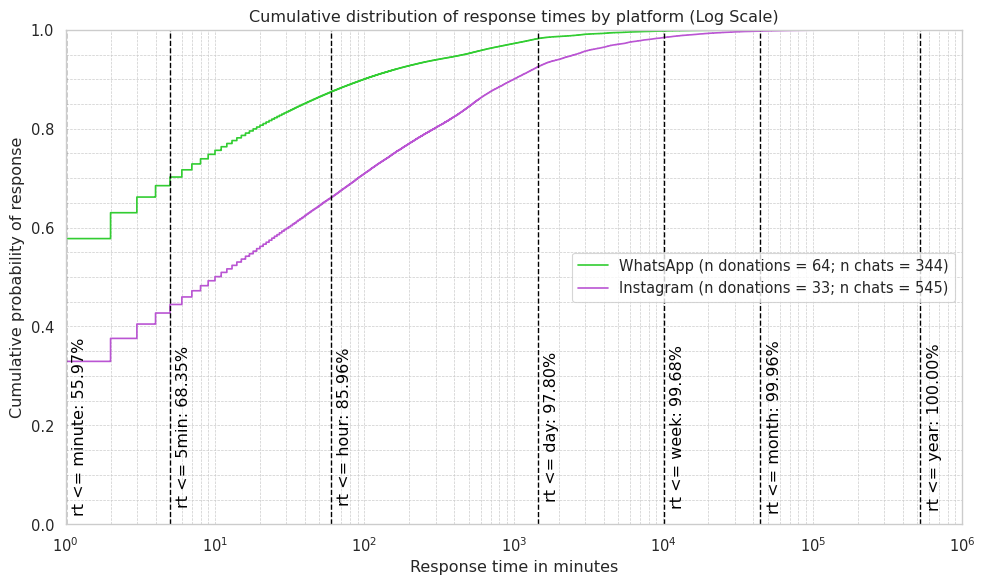

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator

plt_df = response_time_df.copy()

sns.set_theme(context="paper")
sns.set_style("whitegrid")
font_scale = 1.2
sns.set_context("paper", font_scale=font_scale)
plt.figure(figsize=(10, 6))

hour = 60  # 3600 for second_level temporal res
top_n = None

wa_df = plt_df[plt_df.data_source_id == 2]
ig_df = plt_df[plt_df.data_source_id == 3]

print("WhatsApp messages with <=5min RT:",wa_df[wa_df.rt <= 5].count()[0]/len(wa_df))
print("Instagram messages with <=5min RT:",ig_df[ig_df.rt <= 5].count()[0]/len(ig_df))

if top_n:
    ig_df_grouped = ig_df.groupby(["donor_id", "conversation_id"], as_index=False)[
        "word_count"
    ].sum()
    top5_conversations = (
        ig_df_grouped.sort_values(["donor_id", "word_count"], ascending=[False, False])
        .groupby("donor_id")
        .head(top_n)
    )
    ig_df = ig_df.merge(
        top5_conversations[["donor_id", "conversation_id"]],
        on=["donor_id", "conversation_id"],
        how="inner",
    )

# Fix legend labels
wa_n_chats = wa_df.conversation_id.nunique()
ig_n_chats = ig_df.conversation_id.nunique()
donor_counts = (
    plt_df[["donor_id", "data_source_id"]].drop_duplicates().data_source_id.value_counts()
)
new_labels = [
    f"Instagram (n donations = {donor_counts.loc[3]}; n chats = {ig_n_chats})",
    None,
    f"WhatsApp (n donations = {donor_counts.loc[2]}; n chats = {wa_n_chats})",
]

sns.ecdfplot(data=wa_df, x="rt", label=new_labels[-1], color="limegreen")

ig_label = (
    f"Instagram (n donations = {donor_counts.loc[3]}; n chats = {ig_n_chats})"
    if not top_n
    else f"Instagram top {top_n} per donor ((n donations = {donor_counts.loc[3]}; n chats = {ig_n_chats})"
)
sns.ecdfplot(data=ig_df, x="rt", label=ig_label, color="mediumorchid")
legend = plt.legend(labels=new_labels, title="Data Source")

# Set the x scale to logarithmic
plt.xscale("log")

# Add labels and title
plt.title("Cumulative distribution of response times by platform (Log Scale)")
plt.xlabel("Response time in minutes")
plt.ylabel("Cumulative probability of response")
plt.xticks(minor=True)
# Add a legend
plt.minorticks_on()
plt.tick_params(axis="y", which="minor", length=4, color="gray")

# Set the major and minor ticks for the x-axis
plt.gca().xaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs="auto", numticks=100))

# Customize the minor ticks on the x-axis
plt.tick_params(axis="x", which="minor", length=4, color="gray")
text_x_offset = 1.1
text_y_offset = 0.165 * font_scale
df_size_before = plt_df.count()[0]


positions = {
    "minute": 1,
    "5min": 5,
    "hour": 60,
    "day": 24 * 60,
    "week": 24 * 60 * 7,
    "month": 24 * 60 * 31,
    "year" : 24 * 60 * 365,
}
for label, pos in positions.items():
    plt.axvline(x=pos, color="black", linestyle="--", linewidth=1)
    later_df = plt_df[plt_df.rt <= pos]
    plt.text(
        pos * text_x_offset,
        plt.ylim()[-1] * text_y_offset,
        f"rt <= {label}: {(later_df.count()[0] / df_size_before) * 100:.2f}%",
        rotation=90,
        verticalalignment="center",
        color="black",
    )


# Show grid for both major and minor ticks
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.xlim(left=1, right=1e6)

plt.tight_layout()
plt.legend()
if top_n:
    plt.savefig(f"./figures/rt_ecdf_by_source_IGtop{top_n}.png")
else:
    plt.savefig("./figures/rt_ecdf_by_source.pdf")
plt.show()

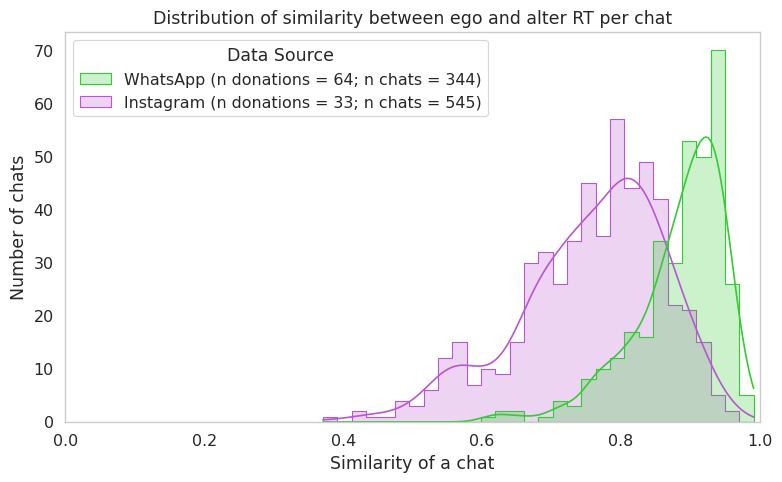

In [ ]:
import pandas as pd
from scipy.spatial.distance import jensenshannon
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.3)

jsd_base = response_time_config.jsd_base
jsd_plot_xlim = 1.0 if jsd_base == 2 else np.sqrt(np.log(2))

# Define bins and labels
bin_edges = [0, 1, 2, 5, 15, 30, 60, float("inf")]
bin_labels = ["<=1min", ">1-2min", "3-5min", "6-15min", "16-30min", "31-60min", ">60min"]

plotting_df = response_time_df.copy()
plotting_df.rt = plotting_df.rt.fillna(pd.Timedelta(seconds=0))

# Bin the response times
plotting_df["rt_bin"] = pd.cut(plotting_df["rt"], bins=bin_edges, labels=bin_labels, right=True)

wa_n_chats = plotting_df[plotting_df.data_source_id == 2].conversation_id.nunique()
ig_n_chats = plotting_df[plotting_df.data_source_id == 3].conversation_id.nunique()

# Initialize list to hold distances and metadata
jsd_records = []

# Group by conversation
for conv_id, group in plotting_df.groupby("conversation_id"):
    counts = group.groupby(["sender", "rt_bin"]).size().unstack(fill_value=0)

    # Skip if either group is missing
    if "ego" not in counts.index or "alter" not in counts.index:
        print("Group missing")
        continue

    # Get raw counts
    ego_dist = counts.loc["ego"].values
    alter_dist = counts.loc["alter"].values

    # Skip if either group has no values
    if ego_dist.sum() == 0 or alter_dist.sum() == 0:
        print("No values")
        continue

    # Normalize to probability distributions
    ego_dist = ego_dist / ego_dist.sum()
    alter_dist = alter_dist / alter_dist.sum()

    # Compute JSD
    jsd = 1 - jensenshannon(ego_dist, alter_dist, base=jsd_base)

    # Get the unique data_source_id(s) for this conversation
    source_ids = group["data_source_id"].unique()
    if len(source_ids) != 1:
        continue  # Skip if there's ambiguity
    data_source_id = source_ids[0]

    # Append to records
    jsd_records.append({"conversation_id": conv_id, "jsd": jsd, "data_source_id": data_source_id})

# Create DataFrame for plotting
jsd_df = pd.DataFrame(jsd_records)

# Plot histogram with hue
plt.figure(figsize=(8, 5))
pal = ["limegreen", "mediumorchid"]
ax = sns.histplot(
    data=jsd_df, x="jsd", hue="data_source_id", bins=30, kde=True, element="step", palette=pal
)

donor_counts = (
    plotting_df[["donor_id", "data_source_id"]].drop_duplicates().data_source_id.value_counts()
)

new_labels = [
    f"Instagram (n donations = {donor_counts.loc[3]}; n chats = {ig_n_chats})",
    None,
    f"WhatsApp (n donations = {donor_counts.loc[2]}; n chats = {wa_n_chats})",
]

legend = plt.legend(labels=new_labels, title="Data Source")
plt.legend(
    handles=legend.legend_handles[2:] + legend.legend_handles[:1],
    labels=new_labels[2:] + new_labels[:1],
    title="Data Source",
)
plt.xlim(left=0, right=jsd_plot_xlim)
plt.xlabel("Similarity of a chat")
plt.ylabel("Number of chats")
plt.title("Distribution of similarity between ego and alter RT per chat")
plt.grid(False)
plt.tight_layout()
plt.savefig("./figures/per_chat_sim_by_source.pdf")
plt.show()

In [22]:
jsd_dict = {
    "mean": jsd_df.jsd.mean(),
    "mean_wa": jsd_df[jsd_df.data_source_id == 2].jsd.mean(),
    "mean_ig": jsd_df[jsd_df.data_source_id == 3].jsd.mean(),
    "median": jsd_df.jsd.median(),
    "median_wa": jsd_df[jsd_df.data_source_id == 2].jsd.median(),
    "median_ig": jsd_df[jsd_df.data_source_id == 3].jsd.median(),
    "sd": jsd_df.jsd.std(),
    "sd_wa": jsd_df[jsd_df.data_source_id == 2].jsd.std(),
    "sd_ig": jsd_df[jsd_df.data_source_id == 3].jsd.std(),
    "skew": jsd_df.jsd.skew(),
    "skew_wa": jsd_df[jsd_df.data_source_id == 2].jsd.skew(),
    "skew_ig": jsd_df[jsd_df.data_source_id == 3].jsd.skew(),
    "kurtosis": jsd_df.jsd.kurtosis(),
    "kurtosis_wa": jsd_df[jsd_df.data_source_id == 2].jsd.kurtosis(),
    "kurtosis_ig": jsd_df[jsd_df.data_source_id == 3].jsd.kurtosis(),
}
save_dict_as_csv(dictionary=jsd_dict, filepath=Path("./data/jsd_stats.dat"))

11589


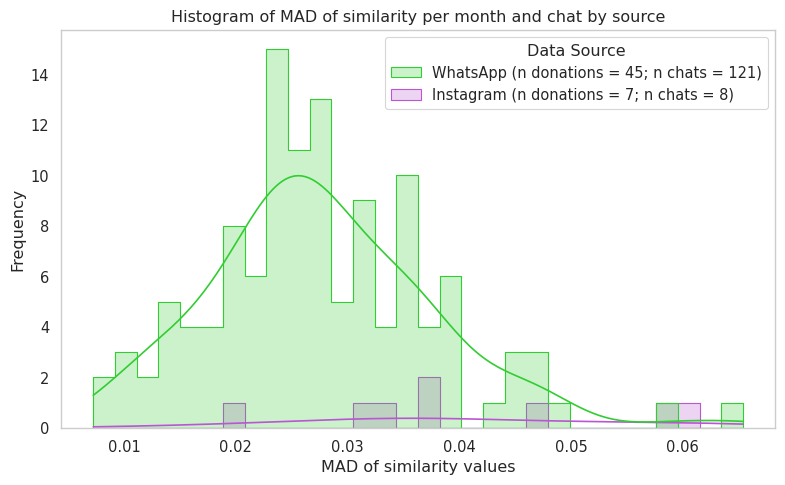

Thresholds: monts per chat=5; min msg=70, jsd base=2.0


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import jensenshannon

# Settings
min_msg_per_month_thresh = 70
min_months_per_chat = 5
sns.set_context("paper", font_scale=1.2)


plotting_df = response_time_df.copy()
plotting_df.rt = plotting_df.rt.fillna(pd.Timedelta(seconds=0))  # Shouldn't be required

# Binning
bin_edges = [0, 1, 2, 5, 15, 30, 60, float("inf")]
bin_labels = ["<=1min", ">1-2min", "3-5min", "6-15min", "16-30min", "31-60min", ">60min"]
plotting_df["rt_bin"] = pd.cut(plotting_df["rt"], bins=bin_edges, labels=bin_labels, right=True)

plotting_df["month"] = plotting_df["datetime"].dt.to_period("M")

# Compute JSD per conversation per month
records = []
skipped_months = 0

for (conv_id, month), group in plotting_df.groupby(["conversation_id", "month"]):
    sender_counts = group["sender"].value_counts()
    if (
        sender_counts.get("ego", 0) < min_msg_per_month_thresh
        or sender_counts.get("alter", 0) < min_msg_per_month_thresh
    ):
        skipped_months += 1
        continue

    counts = group.groupby(["sender", "rt_bin"]).size().unstack(fill_value=0)
    if "ego" not in counts.index or "alter" not in counts.index:
        continue

    ego = counts.loc["ego"].values
    alter = counts.loc["alter"].values

    if ego.sum() == 0 or alter.sum() == 0:
        continue

    ego = ego / ego.sum()
    alter = alter / alter.sum()

    jsd = 1.0 - jensenshannon(ego, alter, base=jsd_base)

    donor_ids = group["donor_id"].unique()
    assert len(donor_ids) == 1, "!= 1 donor ID"

    source_ids = group["data_source_id"].unique()
    assert len(source_ids) == 1, "!=1 data source"
    data_source_id = source_ids[0]

    records.append(
        {
            "conversation_id": conv_id,
            "month": str(month),
            "donor_id": donor_ids[0],
            "jsd": jsd,
            "data_source_id": data_source_id,
        }
    )
print(skipped_months)
monthly_jsd_df = pd.DataFrame(records)

# Filter for at least n months of data
val_counts = monthly_jsd_df["conversation_id"].value_counts()
valid_convs = val_counts[val_counts > min_months_per_chat].index
filtered_monthly_jsd_df = monthly_jsd_df[monthly_jsd_df.conversation_id.isin(valid_convs)]

# Compute CV per conversation
mad_df = (
    filtered_monthly_jsd_df.groupby("conversation_id")["jsd"]
    .agg(lambda x: np.median(np.abs(x - np.median(x))))
    .reset_index(name="mad")
)


# Get donor_id and data_source_id
donor_map = filtered_monthly_jsd_df[
    ["conversation_id", "donor_id", "data_source_id"]
].drop_duplicates()
mad_df = mad_df.merge(donor_map, on="conversation_id")

# Plot histogram with hue by data_source_id
plt.figure(figsize=(8, 5))
pal = ["limegreen", "mediumorchid"]
ax = sns.histplot(
    data=mad_df, x="mad", hue="data_source_id", bins=30, kde=True, element="step", palette=pal
)

# Get number of chats by source for custom legend
source_counts = mad_df.data_source_id.value_counts()
ig_n_chats = source_counts.loc[3]
wa_n_chats = source_counts.loc[2]

donor_counts = (
    mad_df[["donor_id", "data_source_id"]].drop_duplicates().data_source_id.value_counts()
)

new_labels = [
    f"Instagram (n donations = {donor_counts.loc[3]}; n chats = {ig_n_chats})",
    None,
    f"WhatsApp (n donations = {donor_counts.loc[2]}; n chats = {wa_n_chats})",
]

legend = plt.legend(labels=new_labels, title="Data Source")
plt.legend(
    handles=legend.legend_handles[2:] + legend.legend_handles[:1],
    labels=new_labels[2:] + new_labels[:1],
    title="Data Source",
)

plt.xlabel("MAD of similarity values")
plt.ylabel("Frequency")
plt.title("Histogram of MAD of similarity per month and chat by source")
plt.grid(False)
plt.tight_layout()
plt.savefig(
    f"./figures/per_chat_sim_MAD_minMonths{min_months_per_chat}_minMsg{min_msg_per_month_thresh}.pdf"
)
plt.show()
print(
    f"Thresholds: monts per chat={min_months_per_chat}; min msg={min_msg_per_month_thresh}, jsd base={jsd_base}"
)

0 a4c6f1e1-96d3-42a0-a2e6-fad981fd082a


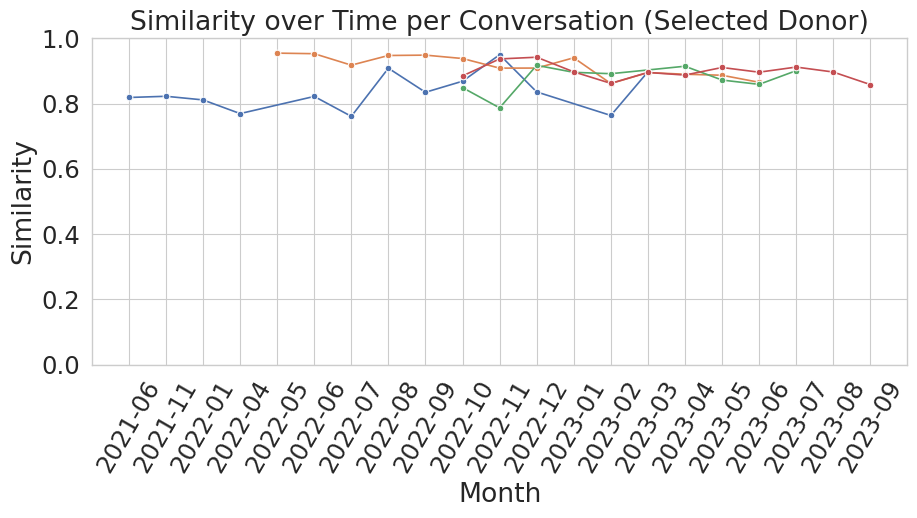

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("paper", font_scale=2.0)

# Filter the DataFrame for the specified donor
donor_list = [
    "a4c6f1e1-96d3-42a0-a2e6-fad981fd082a",
]

for i, donor in enumerate(donor_list):
    donor_df = filtered_monthly_jsd_df[filtered_monthly_jsd_df["donor_id"] == donor].copy()
    # Ensure the month column is in datetime format (if it's a string or Period)
    if donor_df["month"].dtype.name == "string" or donor_df["month"].dtype.name.startswith(
        "period"
    ):
        donor_df["month"] = pd.to_datetime(donor_df["month"].astype(str))
    donor_df = donor_df.sort_values("month")
    # if i > 4:
    #     break

    if donor_df.empty:
        continue

    if donor_df.conversation_id.nunique() < 4:
        continue
    else:
        print(i, donor)

    # Create the line plot
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=donor_df, x="month", y="jsd", hue="conversation_id", marker="o")

    plt.title("Similarity over Time per Conversation (Selected Donor)")
    plt.ylim(0, 1)
    plt.xlabel("Month")
    plt.ylabel("Similarity")
    plt.legend([], [], frameon=False)
    plt.grid(True)
    plt.xticks(rotation=60)
    plt.rcParams.update({"font.size": 34})
    plt.tight_layout()
    plt.savefig(f"./figures/sim_chat_lineplot_{i}.pdf")
    plt.show()


A message limit of >= 100 messages per chat removes 65283/4890778 rows (1.33%) and 3637/4789 convs.
Removed donors: {'e9f61539-78e3-4a26-9290-81294ec486bf', 'd2378a10-125d-40f1-9d66-3e53cbc4bf9f', '9ed0ea9f-3b72-4c3e-8d2d-86b27ba16fa6', '71027f65-a922-4a70-b15b-f9663dbb7ce8', '5c9df3e9-e633-4c99-a2ff-583cc0fb7791', 'bd82e4b3-0d04-4e26-a158-fa43453971d3', '41104d7c-b774-40b4-8e45-b5404bf3b5aa', 'dc1f5c93-4cde-4700-b794-8cab5dad34d8'}
Reducing block messages to one per block removes 2423218/4825495 messages (50.22%)
Removing NaN (due to data transform) removes 1152/2402277 messages (0.05%)
Rounding rt
Removing donations with < 5 chats removes 729153/2401125 rows (30.37%) or 84/181 donations
WhatsApp messages with <=5min RT: 0.6395259186616299
Instagram messages with <=5min RT: 0.39645324395420684


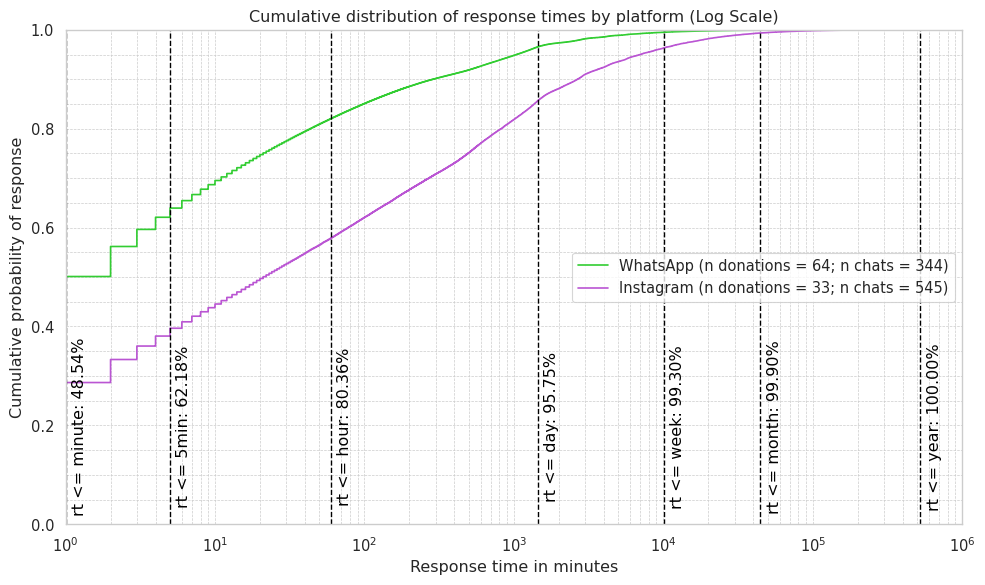

In [25]:
block_last_cfg = response_time_config.model_copy()
block_last_cfg.block_merge = "last"
block_last_df = transform_data(experiment_config=block_last_cfg, df=df, plotting_transforms=True)

sns.set_theme(context="paper")
sns.set_style("whitegrid")
font_scale = 1.2
sns.set_context("paper", font_scale=font_scale)
plt.figure(figsize=(10, 6))

hour = 60  # 3600 for second_level temporal res
top_n = None

wa_df = block_last_df[block_last_df.data_source_id == 2]
ig_df = block_last_df[block_last_df.data_source_id == 3]

print("WhatsApp messages with <=5min RT:",wa_df[wa_df.rt <= 5].count()[0]/len(wa_df))
print("Instagram messages with <=5min RT:",ig_df[ig_df.rt <= 5].count()[0]/len(ig_df))

if top_n:
    ig_df_grouped = ig_df.groupby(["donor_id", "conversation_id"], as_index=False)[
        "word_count"
    ].sum()
    top5_conversations = (
        ig_df_grouped.sort_values(["donor_id", "word_count"], ascending=[False, False])
        .groupby("donor_id")
        .head(top_n)
    )
    ig_df = ig_df.merge(
        top5_conversations[["donor_id", "conversation_id"]],
        on=["donor_id", "conversation_id"],
        how="inner",
    )

# Fix legend labels
wa_n_chats = wa_df.conversation_id.nunique()
ig_n_chats = ig_df.conversation_id.nunique()
donor_counts = (
    block_last_df[["donor_id", "data_source_id"]].drop_duplicates().data_source_id.value_counts()
)
new_labels = [
    f"Instagram (n donations = {donor_counts.loc[3]}; n chats = {ig_n_chats})",
    None,
    f"WhatsApp (n donations = {donor_counts.loc[2]}; n chats = {wa_n_chats})",
]

sns.ecdfplot(data=wa_df, x="rt", label=new_labels[-1], color="limegreen")

ig_label = (
    f"Instagram (n donations = {donor_counts.loc[3]}; n chats = {ig_n_chats})"
    if not top_n
    else f"Instagram top {top_n} per donor ((n donations = {donor_counts.loc[3]}; n chats = {ig_n_chats})"
)
sns.ecdfplot(data=ig_df, x="rt", label=ig_label, color="mediumorchid")
legend = plt.legend(labels=new_labels, title="Data Source")

# Set the x scale to logarithmic
plt.xscale("log")

# Add labels and title
plt.title("Cumulative distribution of response times by platform (Log Scale)")
plt.xlabel("Response time in minutes")
plt.ylabel("Cumulative probability of response")
plt.xticks(minor=True)
# Add a legend
plt.minorticks_on()
plt.tick_params(axis="y", which="minor", length=4, color="gray")

# Set the major and minor ticks for the x-axis
plt.gca().xaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
plt.gca().xaxis.set_minor_locator(LogLocator(base=10.0, subs="auto", numticks=100))

# Customize the minor ticks on the x-axis
plt.tick_params(axis="x", which="minor", length=4, color="gray")
text_x_offset = 1.1
text_y_offset = 0.165 * font_scale
df_size_before = block_last_df.count()[0]


positions = {
    "minute": 1,
    "5min": 5,
    "hour": 60,
    "day": 24 * 60,
    "week": 24 * 60 * 7,
    "month": 24 * 60 * 31,
    "year" : 24 * 60 * 365,
}
for label, pos in positions.items():
    plt.axvline(x=pos, color="black", linestyle="--", linewidth=1)
    later_df = block_last_df[block_last_df.rt <= pos]
    plt.text(
        pos * text_x_offset,
        plt.ylim()[-1] * text_y_offset,
        f"rt <= {label}: {(later_df.count()[0] / df_size_before) * 100:.2f}%",
        rotation=90,
        verticalalignment="center",
        color="black",
    )


# Show grid for both major and minor ticks
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.xlim(left=1, right=1e6)

plt.tight_layout()
plt.legend()
plt.savefig("./figures/rt_ecdf_by_source_keeplast.pdf")
plt.show()


# Empirical JSD cutoff estimate
Subsample chat+month combinations with >=200 messages by ego and alter (individually) to find out how lower numbers of messages in a month affect the variance of JSD.

In [26]:
import pandas as pd
import numpy as np
from scipy.spatial.distance import jensenshannon
from tqdm import tqdm

# --------------------------------------------------------------------
# Parameters
# --------------------------------------------------------------------
BIN_EDGES = np.array([0, 1, 2, 5, 15, 30, 60, np.inf], dtype=float)
SAMPLE_SIZES = [20, 35, 50, 70, 100, 150]
N_DRAWS = 400  # increase if you want tighter std estimates
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)


# --------------------------------------------------------------------
# Helpers
# --------------------------------------------------------------------
def binned_proportions(rt_values: np.ndarray, edges: np.ndarray) -> np.ndarray:
    """Return normalized histogram (probabilities) over given edges."""
    if rt_values.size == 0:
        return np.zeros(edges.size - 1, dtype=float)
    counts, _ = np.histogram(rt_values, bins=edges)
    total = counts.sum()
    if total == 0:
        return np.zeros_like(counts, dtype=float)
    return counts / total


# --------------------------------------------------------------------
# Prep data
# --------------------------------------------------------------------
df = response_time_df.copy()
# Clean and restrict to ego/alter rows with valid, non-negative RTs
df = df[df["sender"].isin(["ego", "alter"])].copy()
df["rt"] = pd.to_numeric(df["rt"], errors="coerce")
df = df.dropna(subset=["rt", "datetime", "donor_id", "conversation_id"])
df = df[df["rt"] >= 0]
df["month"] = pd.to_datetime(df["datetime"]).dt.to_period("M")

# --------------------------------------------------------------------
# Build per-group containers and filter groups with ≥200 messages per side
# --------------------------------------------------------------------
group_cols = ["donor_id", "conversation_id", "month"]

# Split once; store arrays per side to avoid repeated filtering
grouped = df.groupby(group_cols, sort=False)

group_payload = []  # list of dicts with group key and arrays
for key, g in grouped:
    ego_rt = g.loc[g["sender"] == "ego", "rt"].to_numpy()
    alter_rt = g.loc[g["sender"] == "alter", "rt"].to_numpy()
    if ego_rt.size >= 200 and alter_rt.size >= 200:
        group_payload.append(
            {
                "key": key,
                "ego_rt": ego_rt,
                "alter_rt": alter_rt,
            }
        )

# Early exit if nothing qualifies
if not group_payload:
    std_by_sample_size = pd.DataFrame(
        {
            "sample_size": SAMPLE_SIZES,
            "n_diffs": [0] * len(SAMPLE_SIZES),
            "std_diff": [np.nan] * len(SAMPLE_SIZES),
            "mean_diff": [np.nan] * len(SAMPLE_SIZES),
        }
    )
else:
    # Compute full-data JSD distance per qualifying group once (scipy returns distance, not divergence)
    for item in group_payload:
        p_full = binned_proportions(item["ego_rt"], BIN_EDGES)
        q_full = binned_proportions(item["alter_rt"], BIN_EDGES)
        item["full_jsd"] = jensenshannon(p_full, q_full, base=jsd_base)  # distance

    # ----------------------------------------------------------------
    # Subsample and aggregate a single STD of (subsample JSD − full JSD) per sample size
    # Use Welford's online algorithm to avoid storing all diffs in memory
    # ----------------------------------------------------------------
    stats = {s: {"n": 0, "mean": 0.0, "M2": 0.0} for s in SAMPLE_SIZES}

    def update(stats_entry, x):
        n = stats_entry["n"] + 1
        delta = x - stats_entry["mean"]
        mean = stats_entry["mean"] + delta / n
        delta2 = x - mean
        M2 = stats_entry["M2"] + delta * delta2
        stats_entry["n"], stats_entry["mean"], stats_entry["M2"] = n, mean, M2

    for item in tqdm(group_payload, desc="Subsampling across all groups"):
        ego_rt = item["ego_rt"]
        alter_rt = item["alter_rt"]
        full_jsd = item["full_jsd"]

        for s in SAMPLE_SIZES:
            if ego_rt.size < s or alter_rt.size < s:
                continue

            for _ in range(N_DRAWS):
                sub_ego = rng.choice(ego_rt, size=s, replace=False)
                sub_alt = rng.choice(alter_rt, size=s, replace=False)

                p_sub = binned_proportions(sub_ego, BIN_EDGES)
                q_sub = binned_proportions(sub_alt, BIN_EDGES)
                sub_jsd = jensenshannon(p_sub, q_sub, base=jsd_base)

                diff = sub_jsd - full_jsd
                update(stats[s], diff)

    rows = []
    for s in SAMPLE_SIZES:
        st = stats[s]
        if st["n"] > 1:
            var = st["M2"] / (st["n"] - 1)
            std = float(np.sqrt(var))
            mean = float(st["mean"])
        else:
            std = np.nan
            mean = np.nan
        rows.append(
            {
                "sample_size": s,
                "n_diffs": st["n"],
                "std_diff": std,
                "mean_diff": mean,
            }
        )

    std_by_sample_size = pd.DataFrame(rows).sort_values("sample_size")

print("STD of (subsample JSD − full JSD) by sample size:\n")
print(std_by_sample_size)


Subsampling across all groups: 100%|██████████| 1022/1022 [01:58<00:00,  8.63it/s]

STD of (subsample JSD − full JSD) by sample size:

   sample_size  n_diffs  std_diff  mean_diff
0           20   408800  0.096945   0.206989
1           35   408800  0.077696   0.138648
2           50   408800  0.066525   0.101804
3           70   408800  0.056564   0.072953
4          100   408800  0.046395   0.048475
5          150   408800  0.035242   0.027171


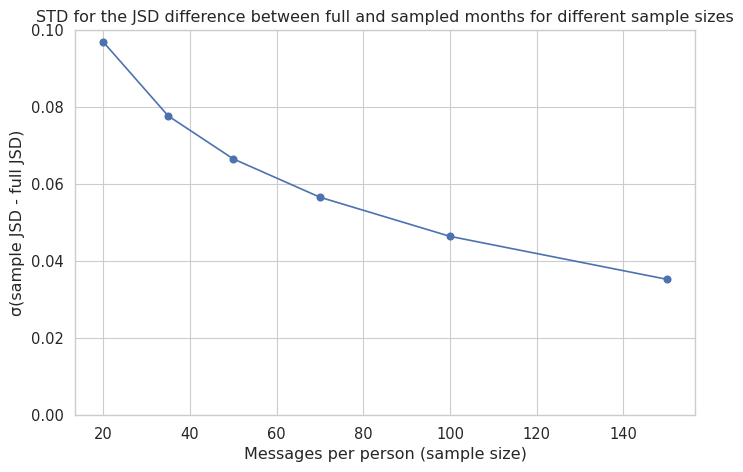

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(std_by_sample_size["sample_size"], std_by_sample_size["std_diff"], marker="o")
plt.xlabel("Messages per person (sample size)")
plt.ylabel("σ(sample JSD - full JSD)")
plt.ylim(bottom=0.0)
plt.title("STD for the JSD difference between full and sampled months for different sample sizes")
plt.grid(True)
plt.savefig("./figures/JSD_subsampling_diff_std.pdf")
plt.show()

Omitted: 536 messages (with upper limit 300)


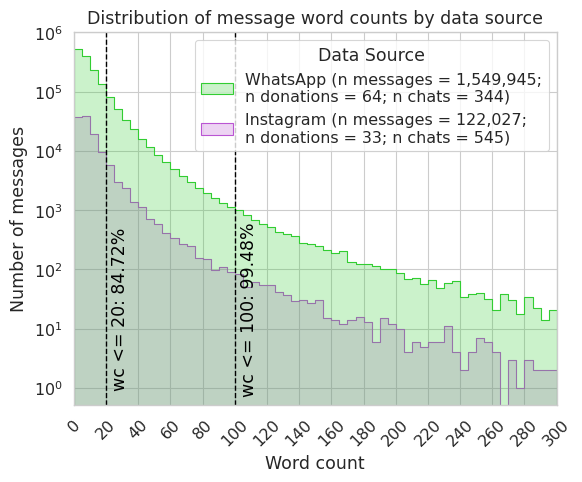

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

font_scale = 1.3
text_x_offset = 3
text_y_offset = 0.00003 * font_scale
wc_limit = 300
x_ticks_stepsize = 20

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=font_scale)

plotting_df = response_time_df.copy()

n_removed = plotting_df[plotting_df.word_count > wc_limit].word_count.count()
hist_df = plotting_df[plotting_df.word_count <= wc_limit]
print(f"Omitted: {n_removed} messages (with upper limit {wc_limit})")

wa_n_msg = plotting_df[plotting_df.data_source_id == 2].shape[0]
ig_n_msg = plotting_df[plotting_df.data_source_id == 3].shape[0]
wa_n_chats = plotting_df.loc[plotting_df.data_source_id == 2, "conversation_id"].nunique()
ig_n_chats = plotting_df.loc[plotting_df.data_source_id == 3, "conversation_id"].nunique()
donor_counts = (
    plotting_df[["donor_id", "data_source_id"]].drop_duplicates().data_source_id.value_counts()
)

plt.figure(figsize=(6, 5))
pal = ["limegreen", "mediumorchid"]

ax = sns.histplot(
    data=hist_df,
    x="word_count",
    hue="data_source_id",
    bins=int(wc_limit / x_ticks_stepsize) * 4,
    kde=False,
    element="step",
    palette=pal,
)
df_size_before = plotting_df.count()[0]

pos = 20
plt.axvline(x=pos, color="black", linestyle="--", linewidth=1)
later_df = plotting_df[plotting_df.word_count <= pos]
plt.text(
    pos + text_x_offset,
    plt.ylim()[-1] * text_y_offset,
    f"wc <= {pos}: {(later_df.count()[0] / df_size_before) * 100:.2f}%",
    rotation=90,
    verticalalignment="center",
    color="black",
)

pos = 100
plt.axvline(x=pos, color="black", linestyle="--", linewidth=1)
later_df = plotting_df[plotting_df.word_count <= pos]
plt.text(
    pos + text_x_offset,
    plt.ylim()[-1] * text_y_offset,
    f"wc <= {pos}: {(later_df.count()[0] / df_size_before) * 100:.2f}%",
    rotation=90,
    verticalalignment="center",
    color="black",
)

new_labels = [
    f"Instagram (n messages = {format(ig_n_msg, ',')};\n"
    f"n donations = {donor_counts.get(3, 0)}; n chats = {ig_n_chats})",
    f"WhatsApp (n messages = {format(wa_n_msg, ',')};\n"
    f"n donations = {donor_counts.get(2, 0)}; n chats = {wa_n_chats})",
]

legend = plt.legend(labels=new_labels, title="Data Source")
plt.legend(
    handles=legend.legend_handles[1:] + legend.legend_handles[:1],
    labels=new_labels[1:] + new_labels[:1],
    title="Data Source",
)
plt.xlim((0, wc_limit))
plt.xlabel("Word count")
plt.ylabel("Number of messages")
plt.yscale("log")
plt.xticks(list(range(0, wc_limit + x_ticks_stepsize, x_ticks_stepsize)))
plt.xticks(rotation=45)
plt.title("Distribution of message word counts by data source")

plt.grid(False)
plt.grid(True, which="major", axis="both")

plt.tight_layout()
plt.savefig("./figures/word_count_hist_by_source.pdf")
plt.show()
